# Xử lý Ảnh (IMP302) - Phân tích Histogram & Tính toán AOD (Average Optical Density)

Notebook này thực hiện các bước:
1. Đọc ảnh từ đường dẫn cục bộ `C:\Users\PC\OneDrive\Desktop\IMP302\images.jpg`.
2. Chuyển đổi ảnh sang ảnh mức xám (Grayscale).
3. Tính ma trận **Mật độ quang học (Optical Density - OD)** theo công thức chuẩn:
   $$\text{OD}(x, y) = -\log_{10}\left(\frac{I(x, y) + 1}{255}\right) = \log_{10}(255) - \log_{10}(I(x, y) + 1)$$
4. Tính **Average Optical Density (AOD)**:
   $$\text{AOD} = \frac{1}{N} \sum_{x, y} \text{OD}(x, y) = \frac{\text{IOD}}{\text{Total Pixels}}$$
5. Vẽ biểu đồ Histogram (cả phân bố Optical Density có vạch AOD và biểu đồ mức xám chuẩn) và in kết quả chính xác.

             KẾT QUẢ TÍNH TOÁN AOD
Kích thước ảnh (M x N)       : 395 x 506 pixels
Tổng số điểm ảnh (M * N)     : 199,870
AOD tính theo pixel f(n,m)   : 167.0730
AOD tính theo Histogram H_f  : 167.0730


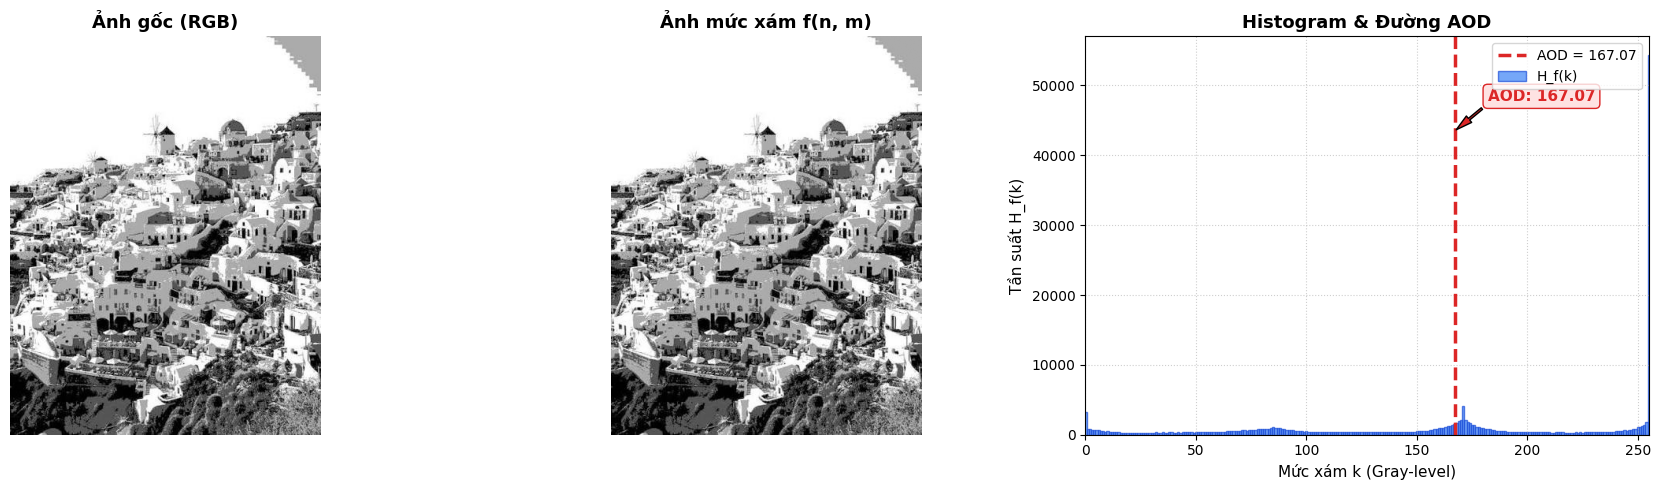

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc ảnh từ đường dẫn
image_path = r"C:\Users\PC\OneDrive\Desktop\IMP302\images.jpg"
img_bgr = cv2.imread(image_path)

if img_bgr is None:
  raise FileNotFoundError(f"Không tìm thấy ảnh tại: {image_path}")

# Chuyển đổi sang ảnh xám và RGB để hiển thị
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Lấy kích thước ảnh N (chiều cao), M (chiều rộng)
N, M = img_gray.shape
total_pixels = M * N

# --- CÁCH 1: Tính theo ma trận điểm ảnh f(n, m) ---
# AOD = (1 / MN) * sum(f(n, m))
aod_pixel = np.sum(img_gray.astype(np.float64)) / total_pixels

# --- CÁCH 2: Tính theo biểu đồ tần suất Histogram H_f(k) ---
# AOD = (1 / MN) * sum(k * H_f(k)) với k chạy từ 0 đến K-1 (K = 256)
hist, _ = np.histogram(img_gray.flatten(), bins=256, range=[0, 256])
k_values = np.arange(256)
aod_hist = np.sum(k_values * hist) / total_pixels

# 3. In kết quả số liệu ra màn hình
print("=" * 50)
print("             KẾT QUẢ TÍNH TOÁN AOD")
print("=" * 50)
print(f"Kích thước ảnh (M x N)       : {M} x {N} pixels")
print(f"Tổng số điểm ảnh (M * N)     : {total_pixels:,}")
print(f"AOD tính theo pixel f(n,m)   : {aod_pixel:.4f}")
print(f"AOD tính theo Histogram H_f  : {aod_hist:.4f}")
print("=" * 50)

# 4. Hiển thị ảnh và biểu đồ Histogram có vạch AOD
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ảnh màu gốc
axes[0].imshow(img_rgb)
axes[0].set_title("Ảnh gốc (RGB)", fontsize=13, fontweight="bold")
axes[0].axis("off")

# Ảnh mức xám
axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Ảnh mức xám f(n, m)", fontsize=13, fontweight="bold")
axes[1].axis("off")

# Histogram mức xám và đường AOD
axes[2].bar(
    k_values,
    hist,
    width=1.0,
    color="#3b82f6",
    edgecolor="#1d4ed8",
    alpha=0.7,
    label="H_f(k)",
)
axes[2].axvline(
    x=aod_hist,
    color="#dc2626",
    linestyle="--",
    linewidth=2.5,
    label=f"AOD = {aod_hist:.2f}",
)

# Thêm nhãn và mũi tên chỉ vị trí AOD
max_freq = np.max(hist)
axes[2].annotate(
    f"AOD: {aod_hist:.2f}",
    xy=(aod_hist, max_freq * 0.8),
    xytext=(aod_hist + 15, max_freq * 0.88),
    arrowprops=dict(facecolor="#dc2626", shrink=0.05, width=1.5, headwidth=6),
    fontsize=11,
    fontweight="bold",
    color="#dc2626",
    bbox=dict(
        boxstyle="round,pad=0.3", facecolor="#fee2e2", edgecolor="#dc2626"
    ),
)

axes[2].set_title(
    "Histogram & Đường AOD", fontsize=13, fontweight="bold"
)
axes[2].set_xlabel("Mức xám k (Gray-level)", fontsize=11)
axes[2].set_ylabel("Tần suất H_f(k)", fontsize=11)
axes[2].set_xlim([0, 255])
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

       KẾT QUẢ HIỆU CHỈNH ĐỘ SÁNG (ADDITIVE OFFSET)
Giá trị L_m = AOD(f_m) ban đầu       : 167.0730
Mức dịch chuyển mục tiêu (K/2)      : 128.0
Độ lệch bù đắp (Offset: K/2 - L_m)  : -39.0730
AOD lý thuyết sau khi offset       : 128.0000
AOD thực tế (sau khi clip [0, 255]) : 129.5234


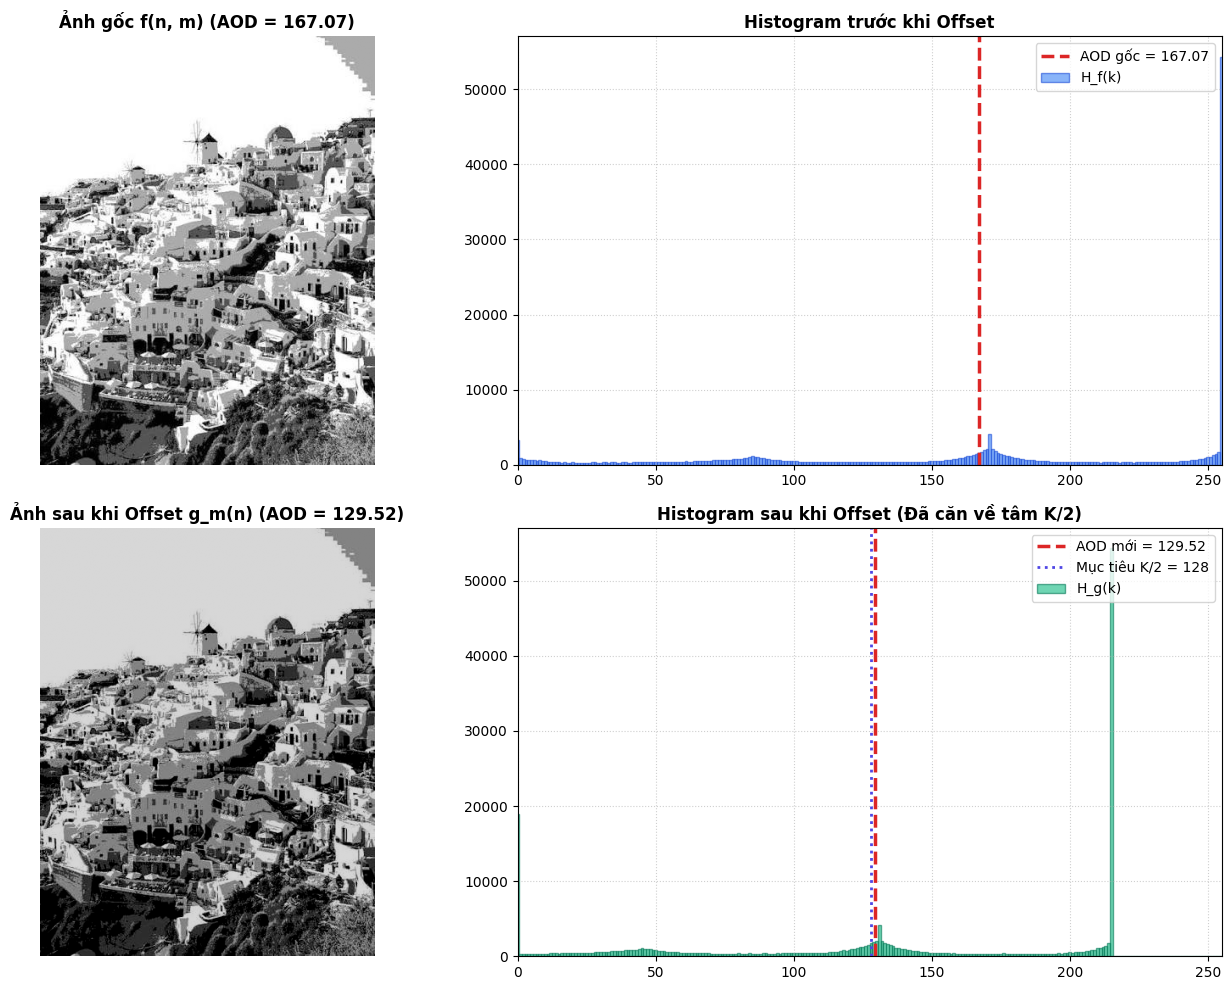

In [2]:
# =====================================================================
# CELL TIẾP THEO: ÁP DỤNG THUẬT TOÁN ADDITIVE IMAGE OFFSET
# Công thức: g_m(n) = f_m(n) - L_m + K/2, trong đó L_m = AOD(f_m)
# =====================================================================

# 1. Khai báo các tham số
K = 256
target_level = K / 2.0  # K/2 = 128
L_m = aod_pixel  # Giá trị AOD(f_m) đã tính từ cell trước

# 2. Áp dụng công thức hiệu chỉnh Offset
# Ép kiểu float để tránh tràn số âm hoặc vượt quá 255 khi cộng trừ
g_float = img_gray.astype(np.float64) - L_m + target_level

# Cắt giá trị (Clipping) về khoảng [0, 255] và chuyển về uint8
img_calibrated = np.clip(g_float, 0, 255).astype(np.uint8)

# 3. Tính toán AOD và Histogram của ảnh sau khi hiệu chỉnh
total_pixels = img_calibrated.size
aod_calibrated = np.sum(img_calibrated.astype(np.float64)) / total_pixels

hist_calibrated, _ = np.histogram(
    img_calibrated.flatten(), bins=256, range=[0, 256]
)

# 4. In các thông số kiểm chứng
print("=" * 55)
print("       KẾT QUẢ HIỆU CHỈNH ĐỘ SÁNG (ADDITIVE OFFSET)")
print("=" * 55)
print(f"Giá trị L_m = AOD(f_m) ban đầu       : {L_m:.4f}")
print(f"Mức dịch chuyển mục tiêu (K/2)      : {target_level:.1f}")
print(f"Độ lệch bù đắp (Offset: K/2 - L_m)  : {target_level - L_m:+.4f}")
print(f"AOD lý thuyết sau khi offset       : {L_m + (target_level - L_m):.4f}")
print(f"AOD thực tế (sau khi clip [0, 255]) : {aod_calibrated:.4f}")
print("=" * 55)

# 5. Xuất hình ảnh và biểu đồ so sánh trực quan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [Hàng 1 - Cột 1] Ảnh mức xám gốc
axes[0, 0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title(
    f"Ảnh gốc f(n, m) (AOD = {L_m:.2f})", fontsize=12, fontweight="bold"
)
axes[0, 0].axis("off")

# [Hàng 1 - Cột 2] Histogram ảnh gốc
axes[0, 1].bar(
    k_values,
    hist,
    width=1.0,
    color="#3b82f6",
    edgecolor="#1d4ed8",
    alpha=0.6,
    label="H_f(k)",
)
axes[0, 1].axvline(
    x=L_m,
    color="#dc2626",
    linestyle="--",
    linewidth=2.5,
    label=f"AOD gốc = {L_m:.2f}",
)
axes[0, 1].set_title(
    "Histogram trước khi Offset", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlim([0, 255])
axes[0, 1].grid(True, linestyle=":", alpha=0.6)
axes[0, 1].legend(loc="upper right")

# [Hàng 2 - Cột 1] Ảnh sau khi offset
axes[1, 0].imshow(img_calibrated, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title(
    f"Ảnh sau khi Offset g_m(n) (AOD = {aod_calibrated:.2f})",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].axis("off")

# [Hàng 2 - Cột 2] Histogram ảnh sau khi offset
axes[1, 1].bar(
    k_values,
    hist_calibrated,
    width=1.0,
    color="#10b981",
    edgecolor="#047857",
    alpha=0.6,
    label="H_g(k)",
)
axes[1, 1].axvline(
    x=aod_calibrated,
    color="#dc2626",
    linestyle="--",
    linewidth=2.5,
    label=f"AOD mới = {aod_calibrated:.2f}",
)
axes[1, 1].axvline(
    x=target_level,
    color="#4f46e5",
    linestyle=":",
    linewidth=2,
    label=f"Mục tiêu K/2 = {target_level:.0f}",
)
axes[1, 1].set_title(
    "Histogram sau khi Offset (Đã căn về tâm K/2)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, linestyle=":", alpha=0.6)
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

TRƯỜNG HỢP             | HỆ SỐ P  | MIN-MAX      | AOD       
Gốc f(n)               | 1.00     | [0, 255]     | 167.07    
Ép lại (Compress)      | 0.50     | [0, 128]     | 83.85     
Giãn ra (Stretch)      | 1.60     | [0, 255]     | 204.83    


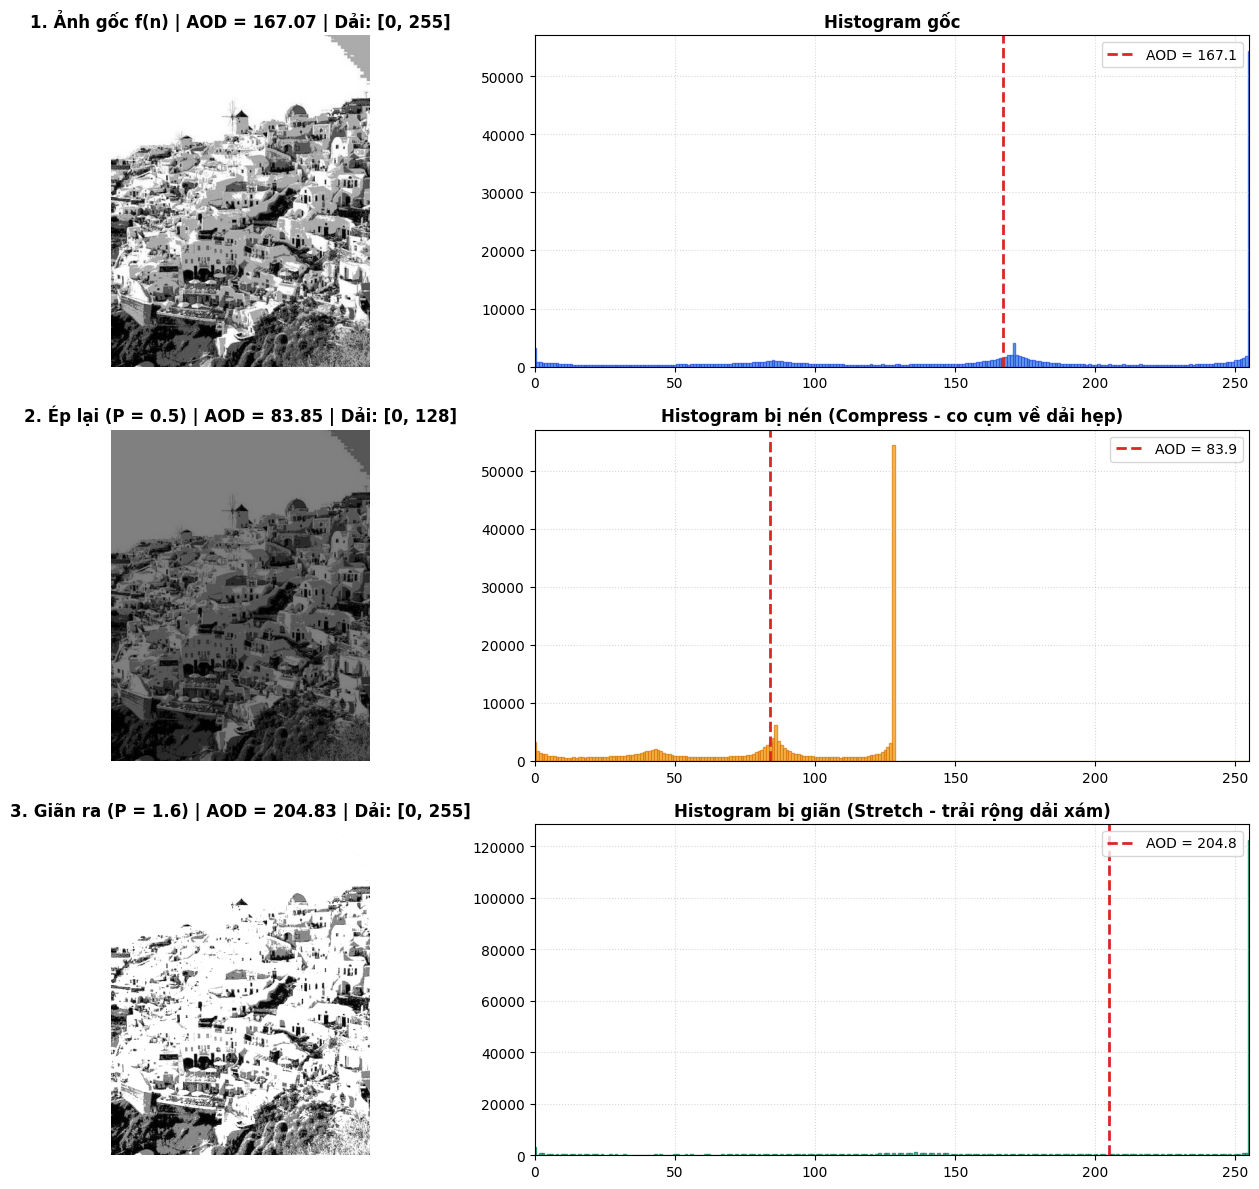

In [3]:
# =====================================================================
# CELL TIẾP THEO: MULTIPLICATIVE IMAGE SCALING (STRETCH & COMPRESS)
# Công thức: g(n) = INT[P * f(n) + 0.5]
# - P > 1: Giãn histogram (stretches)
# - P < 1: Ép / nén histogram (compresses)
# =====================================================================

# 1. Định nghĩa hàm scale theo đúng công thức slide
def multiplicative_scale(img, P):
    # f(n) kiểu float để tính toán
    f = img.astype(np.float64)
    # g(n) = INT[P * f(n) + 0.5]
    g = np.floor(P * f + 0.5)
    # Clip về dải chuẩn [0, 255] và chuyển về uint8
    return np.clip(g, 0, 255).astype(np.uint8)

# 2. Thiết lập hệ số P
P_compress = 0.5   # P < 1: Nén histogram (ép dải xám hẹp lại)
P_stretch  = 1.6   # P > 1: Giãn histogram (kéo dải xám rộng ra)

# Áp dụng công thức
img_compressed = multiplicative_scale(img_gray, P_compress)
img_stretched  = multiplicative_scale(img_gray, P_stretch)

# 3. Tính toán AOD và Histogram cho từng trường hợp
def get_stats_and_hist(img):
    aod = np.mean(img)
    min_val = np.min(img)
    max_val = np.max(img)
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    return aod, min_val, max_val, hist

aod_orig, min_orig, max_orig, hist_orig = get_stats_and_hist(img_gray)
aod_comp, min_comp, max_comp, hist_comp = get_stats_and_hist(img_compressed)
aod_str,  min_str,  max_str,  hist_str  = get_stats_and_hist(img_stretched)

# 4. In bảng thống kê chi tiết ra màn hình
print("=" * 70)
print(f"{'TRƯỜNG HỢP':<22} | {'HỆ SỐ P':<8} | {'MIN-MAX':<12} | {'AOD':<10}")
print("=" * 70)
print(f"{'Gốc f(n)':<22} | {'1.00':<8} | {f'[{min_orig}, {max_orig}]':<12} | {aod_orig:<10.2f}")
print(f"{'Ép lại (Compress)':<22} | {f'{P_compress:<8.2f}'} | {f'[{min_comp}, {max_comp}]':<12} | {aod_comp:<10.2f}")
print(f"{'Giãn ra (Stretch)':<22} | {f'{P_stretch:<8.2f}'} | {f'[{min_str}, {max_str}]':<12} | {aod_str:<10.2f}")
print("=" * 70)

# 5. Hiển thị hình ảnh và Histogram so sánh
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
k_bins = np.arange(256)

# Dòng 1: Ảnh gốc
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"1. Ảnh gốc f(n) | AOD = {aod_orig:.2f} | Dải: [{min_orig}, {max_orig}]", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(k_bins, hist_orig, width=1.0, color='#3b82f6', edgecolor='#1d4ed8', alpha=0.7)
axes[0, 1].axvline(x=aod_orig, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_orig:.1f}')
axes[0, 1].set_title("Histogram gốc", fontweight='bold')
axes[0, 1].set_xlim([0, 255])
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, linestyle=':', alpha=0.5)

# Dòng 2: Ép lại (P < 1)
axes[1, 0].imshow(img_compressed, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f"2. Ép lại (P = {P_compress}) | AOD = {aod_comp:.2f} | Dải: [{min_comp}, {max_comp}]", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(k_bins, hist_comp, width=1.0, color='#f59e0b', edgecolor='#d97706', alpha=0.7)
axes[1, 1].axvline(x=aod_comp, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_comp:.1f}')
axes[1, 1].set_title(f"Histogram bị nén (Compress - co cụm về dải hẹp)", fontweight='bold')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, linestyle=':', alpha=0.5)

# Dòng 3: Giãn ra (P > 1)
axes[2, 0].imshow(img_stretched, cmap='gray', vmin=0, vmax=255)
axes[2, 0].set_title(f"3. Giãn ra (P = {P_stretch}) | AOD = {aod_str:.2f} | Dải: [{min_str}, {max_str}]", fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].bar(k_bins, hist_str, width=1.0, color='#10b981', edgecolor='#047857', alpha=0.7)
axes[2, 1].axvline(x=aod_str, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_str:.1f}')
axes[2, 1].set_title(f"Histogram bị giãn (Stretch - trải rộng dải xám)", fontweight='bold')
axes[2, 1].set_xlim([0, 255])
axes[2, 1].legend(loc='upper right')
axes[2, 1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

       KẾT QUẢ FULL-SCALE HISTOGRAM STRETCH (FSHS)
Giá trị min thực tế (A)        : 0
Giá trị max thực tế (B)        : 128
Dải mức xám trước FSHS         : [0, 128]
Dải mức xám sau FSHS           : [0, 255] (Toàn dải 0 - 255)
Hệ số kéo dãn (K - 1) / (B - A): 1.9922
AOD trước FSHS                 : 83.85
AOD sau FSHS                   : 167.02


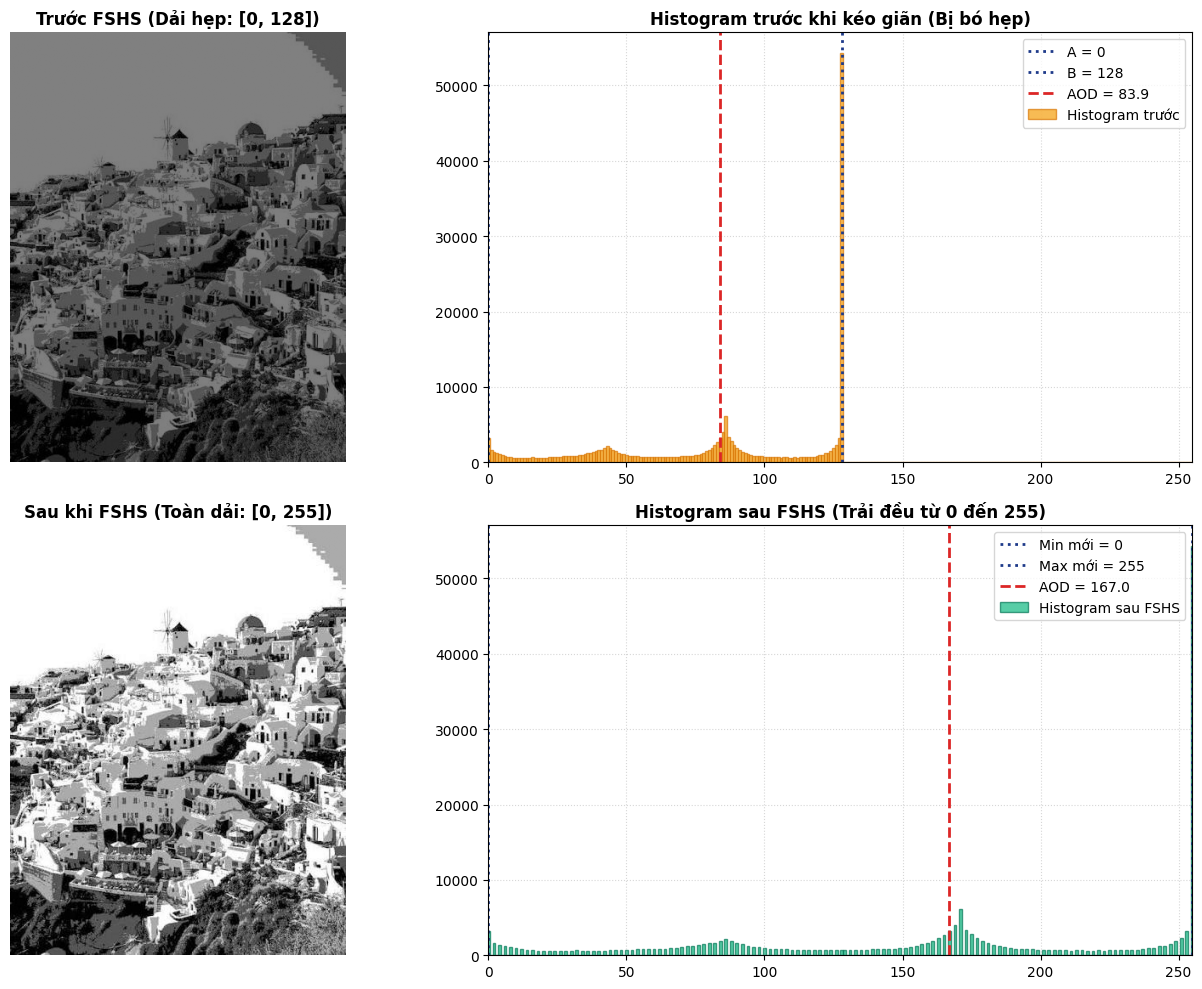

In [4]:
# =====================================================================
# CELL TIẾP THEO: FULL-SCALE HISTOGRAM STRETCH (FSHS)
# Công thức: g(n) = [(K - 1) / (B - A)] * [f(n) - A]
# Trong đó: A = min{f(n)}, B = max{f(n)}, K = 256 (dải [0, K-1] = [0, 255])
# =====================================================================

# 1. Chọn ảnh đầu vào: Thử nghiệm trên ảnh bị nén tương phản (img_compressed)
# để thấy rõ tác dụng kéo dãn toàn dải của FSHS
input_img = img_compressed  # Hoặc dùng img_gray nếu muốn stretch ảnh gốc

f = input_img.astype(np.float64)
K = 256

# 2. Xác định cận min (A) và max (B)
A = np.min(f)
B = np.max(f)

# 3. Áp dụng công thức FSHS
if B - A == 0:
    g = f  # Tránh lỗi chia cho 0 nếu ảnh đơn sắc
else:
    g = ((K - 1) / (B - A)) * (f - A)

# Làm tròn và chuyển về định dạng uint8
img_fshs = np.clip(np.round(g), 0, 255).astype(np.uint8)

# 4. Tính toán số liệu thống kê & Histogram
aod_input = np.mean(input_img)
aod_fshs = np.mean(img_fshs)

hist_in, _ = np.histogram(input_img.flatten(), bins=256, range=[0, 256])
hist_out, _ = np.histogram(img_fshs.flatten(), bins=256, range=[0, 256])

print("=" * 60)
print("       KẾT QUẢ FULL-SCALE HISTOGRAM STRETCH (FSHS)")
print("=" * 60)
print(f"Giá trị min thực tế (A)        : {A:.0f}")
print(f"Giá trị max thực tế (B)        : {B:.0f}")
print(f"Dải mức xám trước FSHS         : [{A:.0f}, {B:.0f}]")
print(f"Dải mức xám sau FSHS           : [{np.min(img_fshs)}, {np.max(img_fshs)}] (Toàn dải 0 - 255)")
print(f"Hệ số kéo dãn (K - 1) / (B - A): {(K - 1) / (B - A):.4f}")
print(f"AOD trước FSHS                 : {aod_input:.2f}")
print(f"AOD sau FSHS                   : {aod_fshs:.2f}")
print("=" * 60)

# 5. Vẽ hình ảnh và Histogram so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_bins = np.arange(256)

# Hàng 1: Trước khi FSHS
axes[0, 0].imshow(input_img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"Trước FSHS (Dải hẹp: [{A:.0f}, {B:.0f}])", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(k_bins, hist_in, width=1.0, color='#f59e0b', edgecolor='#d97706', alpha=0.7, label='Histogram trước')
axes[0, 1].axvline(x=A, color='#1e3a8a', linestyle=':', linewidth=2, label=f'A = {A:.0f}')
axes[0, 1].axvline(x=B, color='#1e3a8a', linestyle=':', linewidth=2, label=f'B = {B:.0f}')
axes[0, 1].axvline(x=aod_input, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_input:.1f}')
axes[0, 1].set_title("Histogram trước khi kéo giãn (Bị bó hẹp)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlim([0, 255])
axes[0, 1].grid(True, linestyle=':', alpha=0.5)
axes[0, 1].legend(loc='upper right')

# Hàng 2: Sau khi FSHS
axes[1, 0].imshow(img_fshs, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f"Sau khi FSHS (Toàn dải: [0, 255])", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(k_bins, hist_out, width=1.0, color='#10b981', edgecolor='#047857', alpha=0.7, label='Histogram sau FSHS')
axes[1, 1].axvline(x=0, color='#1e3a8a', linestyle=':', linewidth=2, label='Min mới = 0')
axes[1, 1].axvline(x=255, color='#1e3a8a', linestyle=':', linewidth=2, label='Max mới = 255')
axes[1, 1].axvline(x=aod_fshs, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_fshs:.1f}')
axes[1, 1].set_title("Histogram sau FSHS (Trải đều từ 0 đến 255)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, linestyle=':', alpha=0.5)
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

PHƯƠNG PHÁP                    | MIN-MAX      | AOD       
1. Ảnh gốc f(n)                | [0, 255]     | 167.07    
2. Log Transform + FSHS        | [0, 255]     | 222.61    
3. Histogram Equalization      | [4, 255]     | 137.33    


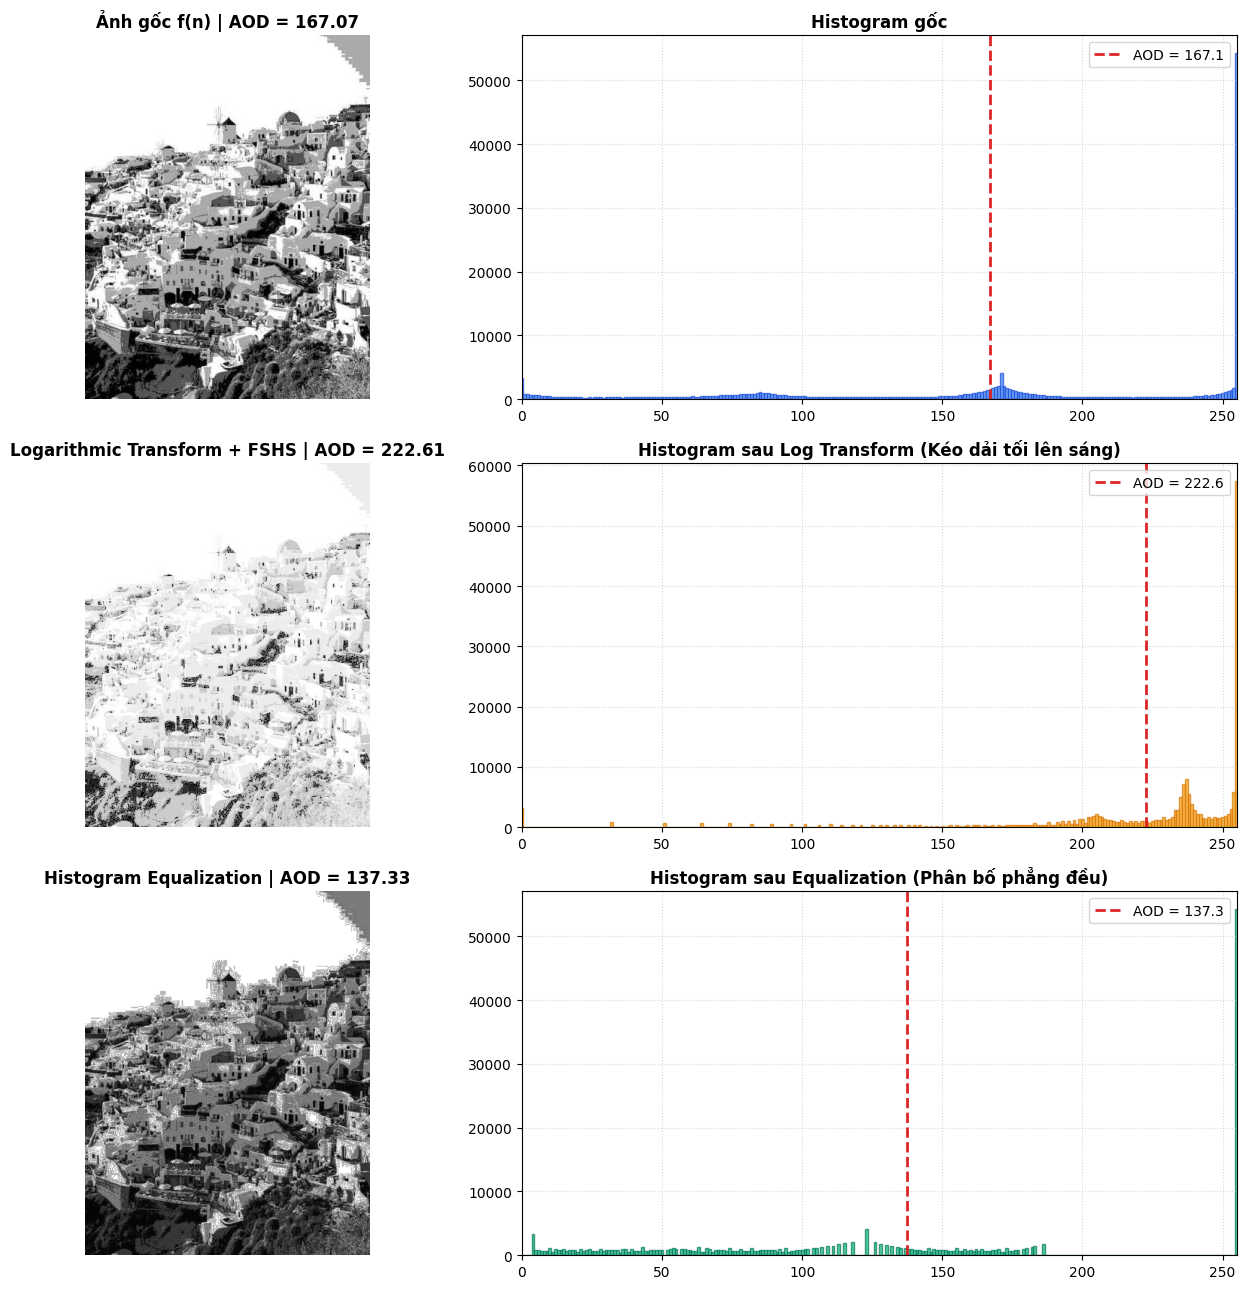

In [5]:
# =====================================================================
# CELL TIẾP THEO: NONLINEAR POINT OPERATIONS
# 1. Logarithmic Transformation: g(n) = FSHS{log[1 + f(n)]}
# 2. Histogram Equalization: p_f(k), CDF P_f(r), và g(n) = P_f[f(n)]
# =====================================================================

K = 256
N, M = img_gray.shape
total_pixels = M * N

# --- PHẦN 1: LOGARITHMIC POINT OPERATION ---
# Bước 1: Tính s = log(1 + f(n))
log_transformed = np.log1p(img_gray.astype(np.float64))

# Bước 2: Áp dụng Full-Scale Histogram Stretch (FSHS) lên kết quả log
A_log = np.min(log_transformed)
B_log = np.max(log_transformed)
img_log = ((K - 1) / (B_log - A_log) * (log_transformed - A_log)).round()
img_log = np.clip(img_log, 0, 255).astype(np.uint8)


# --- PHẦN 2: HISTOGRAM EQUALIZATION ---
# Bước 1: Tính biểu đồ tần suất H_f(k)
H_f, _ = np.histogram(img_gray.flatten(), bins=256, range=[0, 256])

# Bước 2: Chuẩn hóa histogram p_f(k) = (1 / MN) * H_f(k)
p_f = H_f / total_pixels

# Bước 3: Hàm phân bố tích lũy (CDF) P_f(r) = sum_{k=0}^r p_f(k)
P_f = np.cumsum(p_f)

# Bước 4: Ánh xạ g(n) = round((K - 1) * P_f[f(n)])
# Sử dụng trực tiếp giá trị pixel f(n) làm chỉ số tra bảng CDF
lut_equalized = np.round((K - 1) * P_f).astype(np.uint8)
img_equalized = lut_equalized[img_gray]


# --- THỐNG KÊ SỐ LIỆU ---
aod_orig = np.mean(img_gray)
aod_log = np.mean(img_log)
aod_eq = np.mean(img_equalized)

hist_log, _ = np.histogram(img_log.flatten(), bins=256, range=[0, 256])
hist_eq, _ = np.histogram(img_equalized.flatten(), bins=256, range=[0, 256])

print("=" * 68)
print(f"{'PHƯƠNG PHÁP':<30} | {'MIN-MAX':<12} | {'AOD':<10}")
print("=" * 68)
print(f"{'1. Ảnh gốc f(n)':<30} | {f'[{np.min(img_gray)}, {np.max(img_gray)}]':<12} | {aod_orig:<10.2f}")
print(f"{'2. Log Transform + FSHS':<30} | {f'[{np.min(img_log)}, {np.max(img_log)}]':<12} | {aod_log:<10.2f}")
print(f"{'3. Histogram Equalization':<30} | {f'[{np.min(img_equalized)}, {np.max(img_equalized)}]':<12} | {aod_eq:<10.2f}")
print("=" * 68)


# --- VẼ HÌNH VÀ HISTOGRAM ĐỐI CHIẾU ---
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
k_bins = np.arange(256)

# 1. Ảnh gốc
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"Ảnh gốc f(n) | AOD = {aod_orig:.2f}", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(k_bins, H_f, width=1.0, color='#3b82f6', edgecolor='#1d4ed8', alpha=0.7)
axes[0, 1].axvline(x=aod_orig, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_orig:.1f}')
axes[0, 1].set_title("Histogram gốc", fontweight='bold')
axes[0, 1].set_xlim([0, 255])
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, linestyle=':', alpha=0.5)

# 2. Log Transform + FSHS
axes[1, 0].imshow(img_log, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title(f"Logarithmic Transform + FSHS | AOD = {aod_log:.2f}", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(k_bins, hist_log, width=1.0, color='#f59e0b', edgecolor='#d97706', alpha=0.7)
axes[1, 1].axvline(x=aod_log, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_log:.1f}')
axes[1, 1].set_title("Histogram sau Log Transform (Kéo dải tối lên sáng)", fontweight='bold')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, linestyle=':', alpha=0.5)

# 3. Histogram Equalization
axes[2, 0].imshow(img_equalized, cmap='gray', vmin=0, vmax=255)
axes[2, 0].set_title(f"Histogram Equalization | AOD = {aod_eq:.2f}", fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].bar(k_bins, hist_eq, width=1.0, color='#10b981', edgecolor='#047857', alpha=0.7)
axes[2, 1].axvline(x=aod_eq, color='#dc2626', linestyle='--', linewidth=2, label=f'AOD = {aod_eq:.1f}')
axes[2, 1].set_title("Histogram sau Equalization (Phân bố phẳng đều)", fontweight='bold')
axes[2, 1].set_xlim([0, 255])
axes[2, 1].legend(loc='upper right')
axes[2, 1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

     KẾT QUẢ KHỬ NHIỄU BẰNG CỘNG TRUNG BÌNH NHIỀU ẢNH
Số lượng ảnh (n)   | MSE (Sai số)     | PSNR (dB)       | Độ giảm nhiễu (lý thuyết)
-----------------------------------------------------------------
1                  | 490.61           | 21.22           | Giảm 1.0x (σ/√1)         
4                  | 127.27           | 27.08           | Giảm 2.0x (σ/√4)         
16                 | 32.50            | 33.01           | Giảm 4.0x (σ/√16)        
64                 | 8.30             | 38.94           | Giảm 8.0x (σ/√64)        


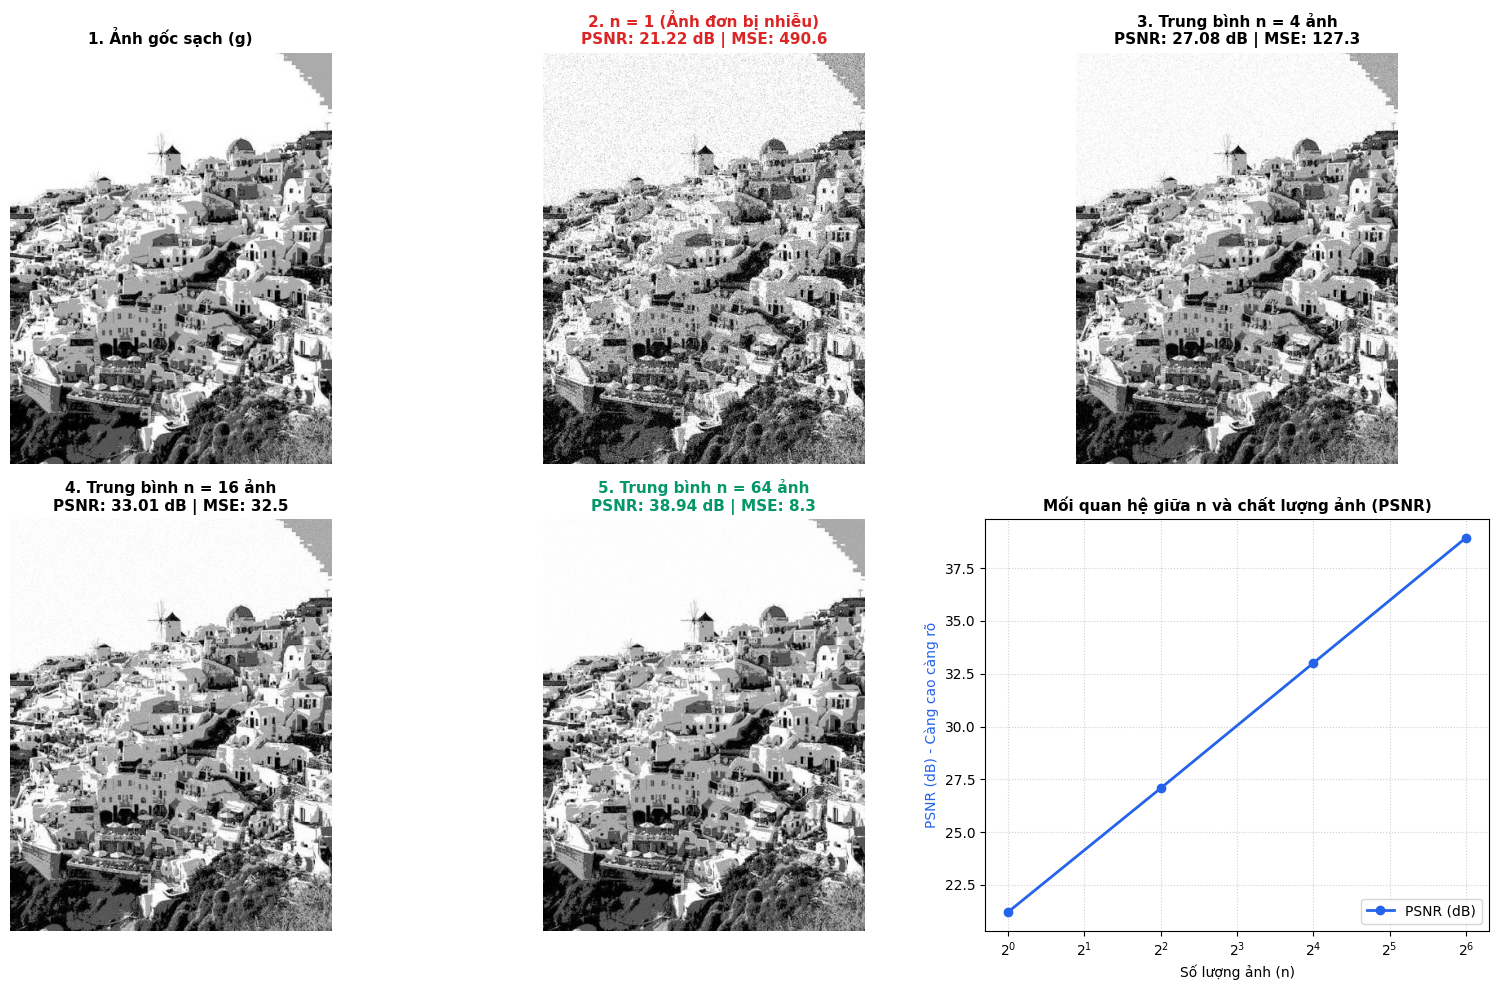

In [6]:
# =====================================================================
# CELL TIẾP THEO: IMAGE-AVERAGING FOR NOISE REDUCTION
# Công thức: f_bar = (1/n) * sum(f_m) = g + (1/n) * sum(q_m) ≈ g
# Giả định: Nhiễu q_m ngẫu nhiên có kỳ vọng bằng 0 (Zero-mean Gaussian noise)
# =====================================================================

# 1. Khởi tạo ảnh gốc sạch (clean image g)
g = img_gray.astype(np.float64)
H, W = g.shape

# Thiết lập thông số nhiễu Gaussian (kỳ vọng mean = 0, độ lệch chuẩn sigma)
mean_noise = 0.0
sigma_noise = 25.0  # Mức độ nhiễu
np.random.seed(42)

# 2. Hàm sinh danh sách n ảnh bị nhiễu f_m = g + q_m
def generate_noisy_images(clean_img, n, sigma):
    noisy_list = []
    for _ in range(n):
        # Tạo nhiễu Gaussian q_m có kỳ vọng bằng 0
        q_m = np.random.normal(mean_noise, sigma, clean_img.shape)
        # f_m = g + q_m
        f_m = clean_img + q_m
        noisy_list.append(f_m)
    return noisy_list

# Hàm tính Mean Squared Error (MSE) so với ảnh gốc
def compute_mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

# Hàm tính PSNR (Peak Signal-to-Noise Ratio)
def compute_psnr(img1, img2):
    mse = compute_mse(img1, img2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255.0 ** 2) / mse)

# 3. Thử nghiệm với các số lượng ảnh khác nhau: n = 1, 4, 16, 64
n_values = [1, 4, 16, 64]
max_n = max(n_values)
all_noisy_images = generate_noisy_images(g, max_n, sigma_noise)

results = {}
for n in n_values:
    # Lấy n ảnh đầu tiên và tính trung bình cộng (1/n) * sum(f_m)
    subset = all_noisy_images[:n]
    avg_img = np.mean(subset, axis=0)
    # Clip về dải [0, 255] và chuyển uint8
    avg_img_uint8 = np.clip(np.round(avg_img), 0, 255).astype(np.uint8)
    
    mse = compute_mse(img_gray, avg_img_uint8)
    psnr = compute_psnr(img_gray, avg_img_uint8)
    results[n] = {
        'image': avg_img_uint8,
        'mse': mse,
        'psnr': psnr
    }

# 4. In bảng thông số đánh giá mức độ khử nhiễu
print("=" * 65)
print("     KẾT QUẢ KHỬ NHIỄU BẰNG CỘNG TRUNG BÌNH NHIỀU ẢNH")
print("=" * 65)
print(f"{'Số lượng ảnh (n)':<18} | {'MSE (Sai số)':<16} | {'PSNR (dB)':<15} | {'Độ giảm nhiễu (lý thuyết)':<25}")
print("-" * 65)
for n in n_values:
    mse_val = results[n]['mse']
    psnr_val = results[n]['psnr']
    theory_red = f"Giảm {np.sqrt(n):.1f}x (σ/√{n})"
    print(f"{n:<18} | {mse_val:<16.2f} | {psnr_val:<15.2f} | {theory_red:<25}")
print("=" * 65)

# 5. Xuất hình ảnh so sánh thực tế
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Ảnh gốc sạch
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("1. Ảnh gốc sạch (g)", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# Ảnh với n = 1 (Chỉ 1 ảnh đơn lẻ bị nhiễu nặng)
axes[0, 1].imshow(results[1]['image'], cmap='gray')
axes[0, 1].set_title(f"2. n = 1 (Ảnh đơn bị nhiễu)\nPSNR: {results[1]['psnr']:.2f} dB | MSE: {results[1]['mse']:.1f}", 
                     fontsize=11, fontweight='bold', color='#dc2626')
axes[0, 1].axis('off')

# Ảnh trung bình với n = 4
axes[0, 2].imshow(results[4]['image'], cmap='gray')
axes[0, 2].set_title(f"3. Trung bình n = 4 ảnh\nPSNR: {results[4]['psnr']:.2f} dB | MSE: {results[4]['mse']:.1f}", 
                     fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Ảnh trung bình với n = 16
axes[1, 0].imshow(results[16]['image'], cmap='gray')
axes[1, 0].set_title(f"4. Trung bình n = 16 ảnh\nPSNR: {results[16]['psnr']:.2f} dB | MSE: {results[16]['mse']:.1f}", 
                     fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

# Ảnh trung bình với n = 64
axes[1, 1].imshow(results[64]['image'], cmap='gray')
axes[1, 1].set_title(f"5. Trung bình n = 64 ảnh\nPSNR: {results[64]['psnr']:.2f} dB | MSE: {results[64]['mse']:.1f}", 
                     fontsize=11, fontweight='bold', color='#059669')
axes[1, 1].axis('off')

# Biểu đồ đường thể hiện quan hệ giữa n và PSNR / MSE
ax_plot = axes[1, 2]
ax_plot.plot(n_values, [results[n]['psnr'] for n in n_values], marker='o', color='#2563eb', linewidth=2, label='PSNR (dB)')
ax_plot.set_title("Mối quan hệ giữa n và chất lượng ảnh (PSNR)", fontsize=11, fontweight='bold')
ax_plot.set_xlabel("Số lượng ảnh (n)", fontsize=10)
ax_plot.set_ylabel("PSNR (dB) - Càng cao càng rõ", fontsize=10, color='#2563eb')
ax_plot.set_xscale('log', base=2)
ax_plot.grid(True, linestyle=':', alpha=0.6)
ax_plot.legend(loc='lower right')

plt.tight_layout()
plt.show()

           GEOMETRIC OPERATIONS & MAPPING MATRICES
1. Ma trận dịch chuyển Translation (tx=40, ty=-30):
[[  1.   0.  40.]
 [  0.   1. -30.]]

2. Ma trận Affine xoay quanh tâm (Góc = 35°, Tỷ lệ = 0.85):
[[  0.6963   0.4875 -63.5146]
 [ -0.4875   0.6963 172.8867]]

3. Kích thước ROI gốc: (80, 80) -> Sau khi phóng to: (400, 400)


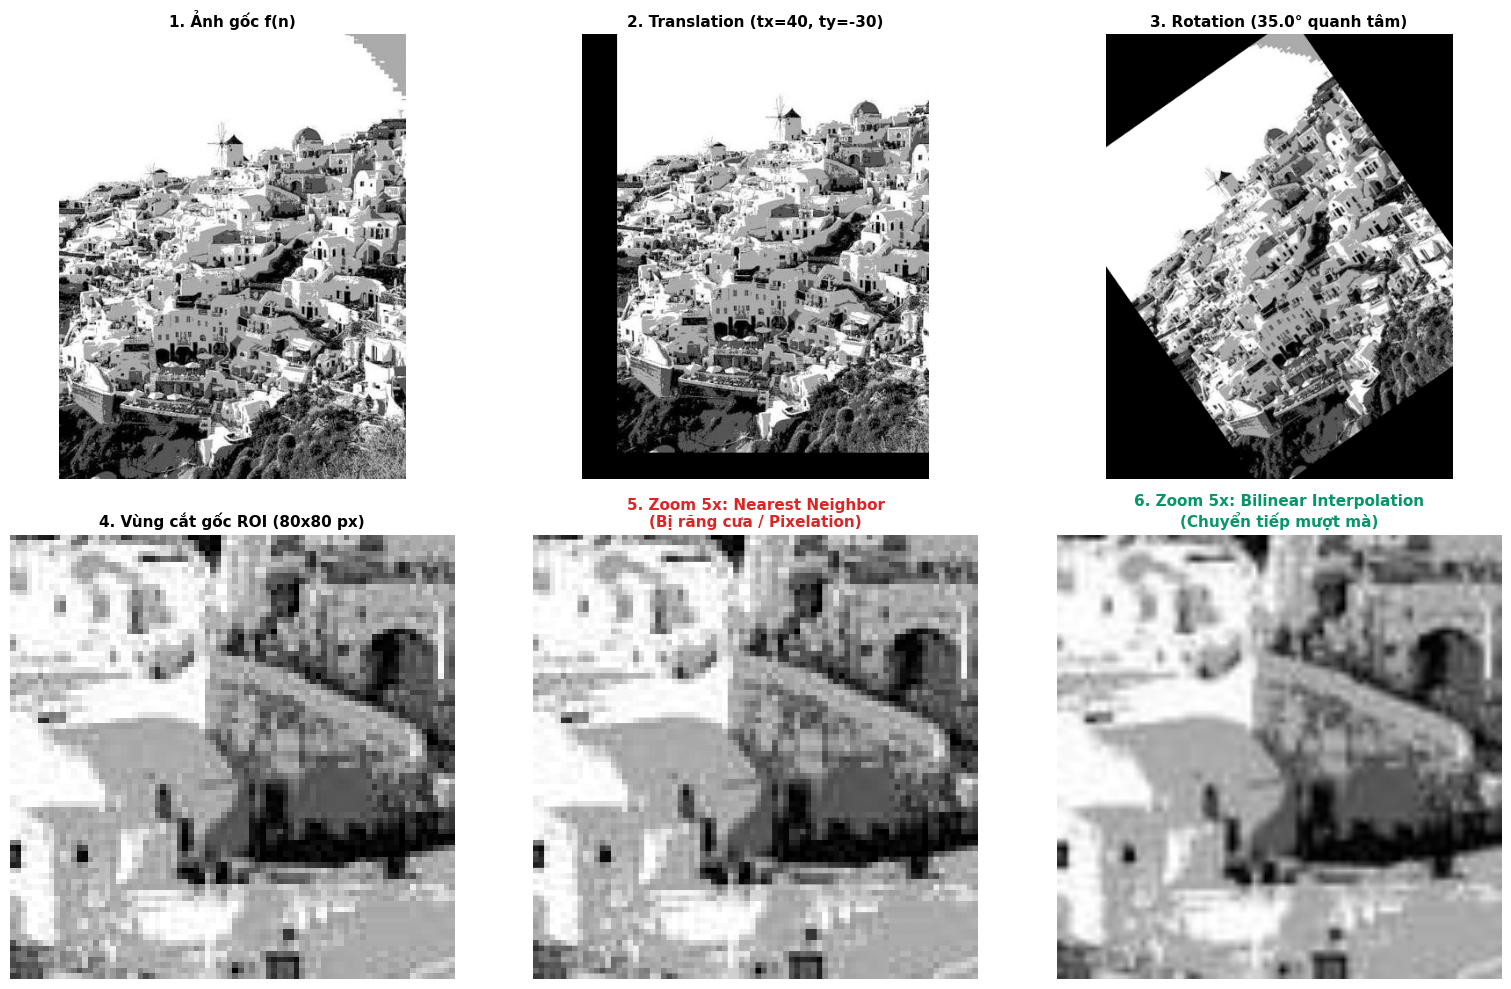

In [7]:
# =====================================================================
# CELL TIẾP THEO: GEOMETRIC IMAGE OPERATIONS
# 1. Spatial Mapping: g(n) = f(n') = f[a(n)] (Dịch chuyển, Xoay, Tỷ lệ)
# 2. Interpolation: Nội suy tọa độ số thực (Nearest Neighbor vs Bilinear)
# =====================================================================

H, W = img_gray.shape

# --- 1. PHÉP DỊCH CHUYỂN (TRANSLATION) ---
# Dịch chuyển ảnh theo trục X (dx) và trục Y (dy)
tx, ty = 40, -30  # Sang phải 40px, lên trên 30px
M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
img_translated = cv2.warpAffine(
    img_gray, M_trans, (W, H), borderMode=cv2.BORDER_CONSTANT, borderValue=0
)

# --- 2. PHÉP XOAY QUANH TÂM (ROTATION WITH ANGLE & SCALE) ---
center = (W // 2, H // 2)
angle = 35.0  # Xoay ngược chiều kim đồng hồ 35 độ
scale_val = 0.85  # Thu nhỏ nhẹ để nằm gọn trong khung hình
M_rot = cv2.getRotationMatrix2D(center, angle, scale_val)
img_rotated = cv2.warpAffine(
    img_gray,
    M_rot,
    (W, H),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0,
)

# --- 3. SO SÁNH NỘI SUY (INTERPOLATION: NEAREST NEIGHBOR vs BILINEAR) ---
# Cắt một vùng chi tiết nhỏ (ROI - Region of Interest) và phóng to 5x
roi = img_gray[150:230, 200:280]  # Vùng cụm nhà Santorini
zoom_factor = 5.0
dim_zoomed = (int(roi.shape[1] * zoom_factor), int(roi.shape[0] * zoom_factor))

# Phương pháp 1: Nearest Neighbor (Gần nhất - nhanh nhưng bị răng cưa pixel hóa)
roi_nearest = cv2.resize(roi, dim_zoomed, interpolation=cv2.INTER_NEAREST)

# Phương pháp 2: Bilinear Interpolation (Nội suy song tuyến tính - mượt mà)
roi_bilinear = cv2.resize(roi, dim_zoomed, interpolation=cv2.INTER_LINEAR)

# --- 4. IN THÔNG SỐ VÀ MA TRẬN BIẾN ĐỔI ---
print("=" * 60)
print("           GEOMETRIC OPERATIONS & MAPPING MATRICES")
print("=" * 60)
print("1. Ma trận dịch chuyển Translation (tx=40, ty=-30):")
print(M_trans)
print("\n2. Ma trận Affine xoay quanh tâm (Góc = 35°, Tỷ lệ = 0.85):")
print(np.round(M_rot, 4))
print(f"\n3. Kích thước ROI gốc: {roi.shape} -> Sau khi phóng to: {dim_zoomed}")
print("=" * 60)

# --- 5. HIỂN THỊ HÌNH ẢNH MINH HỌA ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Ảnh gốc
axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("1. Ảnh gốc f(n)", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

# Dịch chuyển (Translation)
axes[0, 1].imshow(img_translated, cmap="gray")
axes[0, 1].set_title(
    f"2. Translation (tx={tx}, ty={ty})", fontsize=11, fontweight="bold"
)
axes[0, 1].axis("off")

# Xoay (Rotation)
axes[0, 2].imshow(img_rotated, cmap="gray")
axes[0, 2].set_title(
    f"3. Rotation ({angle}° quanh tâm)", fontsize=11, fontweight="bold"
)
axes[0, 2].axis("off")

# Vùng ROI gốc được chọn
axes[1, 0].imshow(roi, cmap="gray")
axes[1, 0].set_title(
    f"4. Vùng cắt gốc ROI (80x80 px)", fontsize=11, fontweight="bold"
)
axes[1, 0].axis("off")

# Phóng to bằng Nearest Neighbor
axes[1, 1].imshow(roi_nearest, cmap="gray")
axes[1, 1].set_title(
    "5. Zoom 5x: Nearest Neighbor\n(Bị răng cưa / Pixelation)",
    fontsize=11,
    fontweight="bold",
    color="#dc2626",
)
axes[1, 1].axis("off")

# Phóng to bằng Bilinear Interpolation
axes[1, 2].imshow(roi_bilinear, cmap="gray")
axes[1, 2].set_title(
    "6. Zoom 5x: Bilinear Interpolation\n(Chuyển tiếp mượt mà)",
    fontsize=11,
    fontweight="bold",
    color="#059669",
)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()